# Time of Emergence — GMSAT, paired t-test — G6-1.5K-SAI & G6-1.5K-HiLLA
## All four models

**Method (central case from `ToE_methods_comparison.ipynb`, method 2):**
For each pair of simulations (one geoengineering-scenario member, one matched SSP2-4.5 member) and a
given year Y, collect all annual-mean GMSAT values from 2035 (deployment start) up to and including
year Y in each simulation. Apply a one-sided Welch's t-test (`scenario < SSP2-4.5`, i.e. cooling
relative to the counterfactual) at p < 0.05. **Member ToE** = first year Y at which the test is
significant.

**Model ToE ("p66"):** rather than requiring *all* members to have emerged (as in `ToE_testing_v6`)
or an interpolated `np.percentile`, we use a count-based threshold: the *k*-th earliest member ToE,
with *k* = ceil(0.66 × N). For N=3 members this is the 2nd-earliest member (2 of 3 emerged); for
MIROC-ES2H's N=10 members this is the 7th-earliest (7 of 10 emerged) — the same rule at every
ensemble size.

**MIROC-ES2H uncertainty:** MIROC-ES2H is the only model with a 10-member ensemble. To make it
comparable with the 3-member models, we bootstrap by drawing all C(10,3) = 120 three-member subsets,
computing the count-based p66 ToE for each, and showing the resulting distribution as a box
(5/25/75/95th percentiles) alongside the exact single-model point estimates from the other models.

**Both scenarios:** G6-1.5K-HiLLA and G6-1.5K-SAI are both branched from — and use the same paired
SSP2-4.5 counterfactual realisations for — each model, so a single SSP2-4.5 dataset per member
serves as the "no intervention" case for both.

**Models and member counts (same for both scenarios):**
| Model | Members |
|---|---|
| MIROC-ES2H | 10 (r01–r10) |
| CESM2-WACCM | 3 (r1–r3) |
| UKESM1-1 | 3 |
| E3SMv3 | 3 |

In [36]:
import sys
import fsspec
import s3fs
import netCDF4
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from scipy import stats
from itertools import combinations
from matplotlib.lines import Line2D

matplotlib.rcParams.update({'font.size': 12})

sys.path.append('../shared/Code_examples/G6-1.5K_example/')
from Utils import weighted_annual_resample

SAI_START   = 2035   # first year of both G6-1.5K-SAI and G6-1.5K-HiLLA
ALPHA       = 0.05
MIN_N       = 2       # minimum years for the cumulative t-test
TREND_YEARS = (2030, 2039)   # decadal warming-rate window for the right-hand panel (straddles the 2035 deployment start)

## 1. File paths

In [19]:
# ── MIROC-ES2H (10 members for both scenarios) ───────────────────────────────
_MIROC = 's3://reflective-persistent-prod-large/MIROC-ES2H'
miroc_n = 10
miroc_hilla_files  = [f'{_MIROC}/G6-1.5K-HiLLA/Amon/tas_G6-1.5K-HiLLA_r{i:02d}.nc' for i in range(1, miroc_n + 1)]
miroc_ssp245_files = [f'{_MIROC}/G6-1.5K-HiLLA/Amon/tas_baseline_r{i:02d}.nc'      for i in range(1, miroc_n + 1)]
miroc_sai_files    = [f'{_MIROC}/G6-1.5K-SAI/Mon/SurfT_G6-1.5K-SAI_r{i:02d}.nc'    for i in range(1, miroc_n + 1)]
# (MIROC's SAI-side "baseline" files are byte-identical to the HiLLA-side SSP2-4.5 files —
#  verified directly — so we load the SSP2-4.5 counterfactual once and reuse it for both scenarios.)

# ── CESM2-WACCM (3 members) ───────────────────────────────────────────────────
_CESM_HiLLA = 's3://reflective-persistent-prod-large/CESM2-WACCM/G6-1.5k-HiLLA'
cesm_hilla_files = [
    [f'{_CESM_HiLLA}/r1/AMON/b.e21.BW.f09_g17.SSP245-G6-1p5K-HiLLA.001.cam.h0.TREFHT.203501-203912.nc',
     f'{_CESM_HiLLA}/r1/AMON/b.e21.BW.f09_g17.SSP245-G6-1p5K-HiLLA.001.cam.h0.TREFHT.204001-208412.nc'],
    [f'{_CESM_HiLLA}/r2/AMON/b.e21.BW.f09_g17.SSP245-G6-1p5K-HiLLA.002.cam.h0.TREFHT.203501-208412.nc'],
    [f'{_CESM_HiLLA}/r3/AMON/b.e21.BW.f09_g17.SSP245-G6-1p5K-HiLLA.003.cam.h0.TREFHT.203501-208412.nc'],
]
# SSP2-4.5 sourced from the public CMIP6 pangeo zarr catalogue; fetched from 2025 onwards
# so the same dataset covers both the t-test (>= 2035) and the 2030-2039 trend window.
_CESM_SAI = 's3://reflective-persistent-prod/alistairduffey/CESM2-WACCM/G6-1.5K-SAI'
cesm_sai_files = [f'{_CESM_SAI}/r{i+1}/AMON/CESM_b.e21.BW.f09_g17.SSP245-G6-1p5K-SAI.00{i+1}.cam.h0.TREFHT.203501-208412.nc'
                  for i in range(3)]

# ── UKESM1-1 (3 members) ──────────────────────────────────────────────────────
_UKESM_HiLLA  = 's3://reflective-persistent-prod-large/UKESM1-1/G6-1p5K-HiLLA'
_UKESM_SSP245 = 's3://reflective-persistent-prod-large/UKESM1-1/SSP245'
_UKESM_SAI    = 's3://reflective-persistent-prod/alistairduffey/UKESM1-1/G6-1.5K-SAI'
ukesm_hilla_members  = ['r12i1p1f2', 'r2i1p1f2', 'r3i1p1f2']
ukesm_ssp245_members = ['r12i1p1f1', 'r2i1p1f1', 'r3i1p1f1']
ukesm_hilla_paths  = [f'{_UKESM_HiLLA}/{m}/apm/Amon/tas/'  for m in ukesm_hilla_members]
ukesm_ssp245_paths = [f'{_UKESM_SSP245}/{m}/ap5/Amon/tas/' for m in ukesm_ssp245_members]
ukesm_sai_paths    = [f'{_UKESM_SAI}/r{i+1}/AMON/'         for i in range(3)]

# ── E3SMv3 (3 members) ─────────────────────────────────────────────────────────
_E3SM = 's3://reflective-persistent-prod-large/E3SMv3/G6-1.5K-HiLLA'
_E3SM_MAP = f'{_E3SM}/maps/map_ne30pg2_to_cmip6_180x360_aave.20200201.nc'
e3sm_runs = ['0101', '0151', '0201']
e3sm_hilla_dirs  = [f'{_E3SM}/v3.LR.ssp245.g6_hilla.sai.{r}/Amon/TREFHT/gn/13112025/' for r in e3sm_runs]
e3sm_ssp245_dirs = [f'{_E3SM}/v3.LR.ssp245_{r}/Amon/TREFHT/gn/13112025/'               for r in e3sm_runs]
# G6-1.5K-SAI already regridded to a regular 180x360 lat/lon grid (Lee et al. archive)
_E3SM_SAI = 's3://reflective-persistent-prod/alistairduffey/E3SMv3/G6-1.5K-SAI'
e3sm_sai_files = [
    f'{_E3SM_SAI}/r1/tas/E3SM_v3.LR.ssp245.0101.g6.sai.TREFHT.203501-208412.nc',
    f'{_E3SM_SAI}/r2/tas/E3SM_v3.LR.ssp245.0151.g6.sai.TREFHT.203501-208412.nc',
    f'{_E3SM_SAI}/r3/tas/E3SM_v3.LR.ssp245.0201.g6.sai.TREFHT.203501-208412.nc',
]

print('File paths defined.')

File paths defined.


## 2. Data loading and global annual mean GMSAT

In [37]:
# ── generic readers (as in ToE_testing_v6) ────────────────────────────────────
def open_nc(path, rename_var=None, set_time_bounds=False):
    with fsspec.open(path, mode='rb') as f:
        ds = xr.open_dataset(f, engine='h5netcdf', chunks={}).load()
    if rename_var:
        ds = ds.rename({rename_var: 'tas'})
    if set_time_bounds:
        from Utils import set_time_to_center_of_bounds
        ds = set_time_to_center_of_bounds(ds, time_bounds_name='time_bnds')
    return ds

def open_concat(path_list, rename_var=None, set_time_bounds=False):
    parts = [open_nc(p, rename_var=rename_var, set_time_bounds=set_time_bounds) for p in path_list]
    return xr.concat(parts, dim='time')

def open_mf_from_path(s3_dir, drop_year=None):
    fs = s3fs.S3FileSystem(anon=False)
    files = sorted(fs.ls(s3_dir.replace('s3://', '')))
    file_objs = [fsspec.open(f's3://{f}', mode='rb').open() for f in files]
    ds = xr.open_mfdataset(file_objs, combine='nested', concat_dim='time', chunks={}).load()
    if drop_year is not None:
        ds = ds.sel(time=(ds.time.dt.year != drop_year))
    return ds

def open_ukesm_sai(path_list):
    """UKESM G6-1.5K-SAI files have non-standard dims (t/temp/ht) — fix them up."""
    ds_list = []
    for path in path_list:
        files = fsspec.open_files(f'{path}*.nc', mode='rb')
        ds = xr.open_mfdataset([f.open() for f in files], combine='nested', concat_dim='time', chunks={}).load()
        ds = ds.isel(time=0).rename({'t': 'time'}).rename({'temp': 'tas'}).isel(ht=0)
        ds_list.append(ds)
    return ds_list

def open_e3sm_dir(s3_dir):
    """Native ne30 grid, time-split files — concatenate and return (years, months, TREFHT)."""
    fs = s3fs.S3FileSystem(anon=False)
    files = sorted(fs.ls(s3_dir.replace('s3://', '')))
    parts = []
    for f in files:
        with fs.open(f, 'rb') as fobj:
            data = fobj.read()
        nc = netCDF4.Dataset('dummy', memory=data)
        time_raw, trefht = nc.variables['time'][:], nc.variables['TREFHT'][:]
        times = netCDF4.num2date(time_raw, nc.variables['time'].units,
                                 getattr(nc.variables['time'], 'calendar', 'standard'))
        parts.append((np.array([t.year for t in times]), trefht))
    years_all  = np.concatenate([p[0] for p in parts])
    trefht_all = np.concatenate([p[1] for p in parts], axis=0)
    return years_all, trefht_all

def e3sm_global_annual_means(dirs, area_w):
    """Area-weighted (native-grid) global annual mean; returns (years, values) tuples."""
    result = []
    for d in dirs:
        years_m, trefht_m = open_e3sm_dir(d)
        gmsat_monthly = (trefht_m * area_w[np.newaxis, :]).sum(axis=1)
        uy = np.unique(years_m)
        result.append((uy, np.array([gmsat_monthly[years_m == y].mean() for y in uy])))
    return result

def global_annual_mean(ds, var='tas', lat_name='lat', lon_name='lon', sort_lat=False):
    """Area-weighted (regular-grid) global annual mean; returns (years, values) tuple."""
    da = ds[var]
    if sort_lat:
        da = da.sortby(lat_name)
    weights = np.cos(np.deg2rad(da[lat_name]))
    weights /= weights.sum()
    gmean = (da * weights).sum(lat_name).mean(lon_name)
    annual = weighted_annual_resample(gmean.to_dataset(name=var), var=var)[var]
    return annual.time.dt.year.values.astype(int), annual.values

print('Reader functions defined.')

Reader functions defined.


In [4]:
# ── MIROC-ES2H ────────────────────────────────────────────────────────────────
print('Loading MIROC-ES2H...')
miroc_hilla_gmsat  = [global_annual_mean(open_nc(f), sort_lat=True) for f in miroc_hilla_files]
miroc_ssp245_gmsat = [global_annual_mean(open_nc(f), sort_lat=True) for f in miroc_ssp245_files]
miroc_sai_gmsat    = [global_annual_mean(open_nc(f, rename_var='SurfT'), sort_lat=True) for f in miroc_sai_files]
print(f'  HiLLA {len(miroc_hilla_gmsat)}, SSP245 {len(miroc_ssp245_gmsat)}, SAI {len(miroc_sai_gmsat)} members')

Loading MIROC-ES2H...


  HiLLA 10, SSP245 10, SAI 10 members


In [6]:
# ── CESM2-WACCM ───────────────────────────────────────────────────────────────
print('Loading CESM2-WACCM...')
cesm_hilla_ds = [
    open_nc(fl[0], rename_var='TREFHT', set_time_bounds=True) if len(fl) == 1
    else open_concat(fl, rename_var='TREFHT', set_time_bounds=True)
    for fl in cesm_hilla_files
]
cesm_sai_ds = [open_nc(f, rename_var='TREFHT', set_time_bounds=True) for f in cesm_sai_files]

print('  Loading CESM2-WACCM SSP245 from CMIP6 pangeo catalogue...')
cmip6_df = pd.read_csv('https://cmip6-pds.s3.amazonaws.com/pangeo-cmip6.csv')
cesm_subset = cmip6_df.query(
    "activity_id=='ScenarioMIP' & source_id=='CESM2-WACCM' "
    "& experiment_id=='ssp245' & table_id=='Amon' & variable_id=='tas'")
cesm_ssp245_ds = []
for i in range(3):
    ds = xr.open_dataset(cesm_subset.zstore.values[i], engine='zarr', consolidated=True,
                         chunks={}, storage_options={'anon': True})
    cesm_ssp245_ds.append(ds.sel(time=ds.time.dt.year >= 2025).load())

cesm_hilla_gmsat  = [global_annual_mean(ds) for ds in cesm_hilla_ds]
cesm_ssp245_gmsat = [global_annual_mean(ds) for ds in cesm_ssp245_ds]
cesm_sai_gmsat    = [global_annual_mean(ds) for ds in cesm_sai_ds]
print(f'  HiLLA {len(cesm_hilla_gmsat)}, SSP245 {len(cesm_ssp245_gmsat)}, SAI {len(cesm_sai_gmsat)} members')

Loading CESM2-WACCM...


/tmp/ipykernel_19650/2665640542.py:14: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  return xr.concat(parts, dim='time')


  Loading CESM2-WACCM SSP245 from CMIP6 pangeo catalogue...


  HiLLA 3, SSP245 3, SAI 3 members


In [7]:
# ── UKESM1-1 ─────────────────────────────────────────────────────────────────
print('Loading UKESM1-1...')
ukesm_hilla_ds  = [open_mf_from_path(p, drop_year=2084) for p in ukesm_hilla_paths]  # missing Dec 2084
ukesm_ssp245_ds = [open_mf_from_path(p).pipe(lambda d: d.sel(time=d.time.dt.year >= 2025))
                   for p in ukesm_ssp245_paths]
ukesm_sai_ds    = open_ukesm_sai(ukesm_sai_paths)

ukesm_hilla_gmsat  = [global_annual_mean(ds) for ds in ukesm_hilla_ds]
ukesm_ssp245_gmsat = [global_annual_mean(ds) for ds in ukesm_ssp245_ds]
ukesm_sai_gmsat    = [global_annual_mean(ds, lat_name='latitude', lon_name='longitude') for ds in ukesm_sai_ds]
print(f'  HiLLA {len(ukesm_hilla_gmsat)}, SSP245 {len(ukesm_ssp245_gmsat)}, SAI {len(ukesm_sai_gmsat)} members')

Loading UKESM1-1...


/tmp/ipykernel_19650/2665640542.py:20: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  ds = xr.open_mfdataset(file_objs, combine='nested', concat_dim='time', chunks={}).load()


/tmp/ipykernel_19650/2665640542.py:20: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  ds = xr.open_mfdataset(file_objs, combine='nested', concat_dim='time', chunks={}).load()


/tmp/ipykernel_19650/2665640542.py:20: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  ds = xr.open_mfdataset(file_objs, combine='nested', concat_dim='time', chunks={}).load()


/tmp/ipykernel_19650/2665640542.py:20: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  ds = xr.open_mfdataset(file_objs, combine='nested', concat_dim='time', chunks={}).load()


...

/tmp/ipykernel_19650/2665640542.py:20: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  ds = xr.open_mfdataset(file_objs, combine='nested', concat_dim='time', chunks={}).load()


/tmp/ipykernel_19650/2665640542.py:30: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'longitude' ('longitude',) The recommendation is to set join explicitly for this case.
  ds = xr.open_mfdataset([f.open() for f in files], combine='nested', concat_dim='time', chunks={}).load()


/tmp/ipykernel_19650/2665640542.py:30: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'longitude' ('longitude',) The recommendation is to set join explicitly for this case.
  ds = xr.open_mfdataset([f.open() for f in files], combine='nested', concat_dim='time', chunks={}).load()


/tmp/ipykernel_19650/2665640542.py:30: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'longitude' ('longitude',) The recommendation is to set join explicitly for this case.
  ds = xr.open_mfdataset([f.open() for f in files], combine='nested', concat_dim='time', chunks={}).load()


  HiLLA 3, SSP245 3, SAI 3 members


In [8]:
# ── E3SMv3 ────────────────────────────────────────────────────────────────────
print('Loading E3SMv3...')
fs_anon = s3fs.S3FileSystem(anon=False)
with fs_anon.open(_E3SM_MAP.replace('s3://', ''), 'rb') as f:
    nc_map = netCDF4.Dataset('dummy', memory=f.read())
e3sm_area_weights = np.array(nc_map.variables['area_a'][:])
e3sm_area_weights /= e3sm_area_weights.sum()

e3sm_hilla_gmsat  = e3sm_global_annual_means(e3sm_hilla_dirs,  e3sm_area_weights)   # native ne30 grid
e3sm_ssp245_gmsat = e3sm_global_annual_means(e3sm_ssp245_dirs, e3sm_area_weights)   # native ne30 grid
e3sm_sai_gmsat    = [global_annual_mean(open_nc(f, rename_var='TREFHT')) for f in e3sm_sai_files]  # regridded 180x360
print(f'  HiLLA {len(e3sm_hilla_gmsat)}, SSP245 {len(e3sm_ssp245_gmsat)}, SAI {len(e3sm_sai_gmsat)} members')

Loading E3SMv3...


  HiLLA 3, SSP245 3, SAI 3 members


In [9]:
# ── collect into one structure: gmsat[model][scenario] = list of (years, values) ─
gmsat = {
    'MIROC-ES2H':  {'HiLLA': miroc_hilla_gmsat,  'SSP245': miroc_ssp245_gmsat,  'SAI': miroc_sai_gmsat},
    'CESM2-WACCM': {'HiLLA': cesm_hilla_gmsat,   'SSP245': cesm_ssp245_gmsat,   'SAI': cesm_sai_gmsat},
    'UKESM1-1':    {'HiLLA': ukesm_hilla_gmsat,  'SSP245': ukesm_ssp245_gmsat,  'SAI': ukesm_sai_gmsat},
    'E3SMv3':      {'HiLLA': e3sm_hilla_gmsat,   'SSP245': e3sm_ssp245_gmsat,   'SAI': e3sm_sai_gmsat},
}
MODELS = list(gmsat.keys())
print('All models loaded:', MODELS)

All models loaded: ['MIROC-ES2H', 'CESM2-WACCM', 'UKESM1-1', 'E3SMv3']


## 3. Time of Emergence — cumulative paired t-test

For each geoengineering-scenario member and its paired SSP2-4.5 realisation, apply the one-sided
cumulative Welch's t-test (as in `ToE_testing_v6` / `ToE_methods_comparison` method 2). The
**model ToE** is the count-based 66th-percentile member (see the notebook intro).

In [38]:
def cumulative_ttest_toe(scen_ts, ssp_ts, start_year=SAI_START, alpha=ALPHA, min_n=MIN_N):
    """One-sided cumulative Welch's t-test ToE for a single member pair.
    scen_ts, ssp_ts: (years, values) tuples. Returns first year Y >= start_year at
    which p < alpha for the cumulative window [start_year, Y], or None.
    """
    g_yrs, g_vals = scen_ts
    s_yrs, s_vals = ssp_ts
    g_mask, s_mask = g_yrs >= start_year, s_yrs >= start_year
    g_yrs, g_vals = g_yrs[g_mask], g_vals[g_mask]
    s_yrs, s_vals = s_yrs[s_mask], s_vals[s_mask]
    end_year = int(min(g_yrs.max(), s_yrs.max()))
    for Y in range(start_year, end_year + 1):
        g_win, s_win = g_vals[g_yrs <= Y], s_vals[s_yrs <= Y]
        if min(len(g_win), len(s_win)) < min_n:
            continue
        _, p = stats.ttest_ind(g_win, s_win, equal_var=False, alternative='less')
        if p < alpha:
            return Y
    return None


def count_based_p66(member_toes):
    """k-th earliest member ToE, k = ceil(0.66 * N) — 'k of N members past ToE'."""
    valid = sorted(t for t in member_toes if t is not None)
    k = int(np.ceil(0.66 * len(member_toes)))
    return valid[k - 1] if len(valid) >= k else None


# ── per-member ToEs for every model / scenario ────────────────────────────────
member_toes = {m: {} for m in MODELS}
for m in MODELS:
    ssp_list = gmsat[m]['SSP245']
    for scen in ['HiLLA', 'SAI']:
        scen_list = gmsat[m][scen]
        n = min(len(scen_list), len(ssp_list))
        member_toes[m][scen] = [cumulative_ttest_toe(scen_list[i], ssp_list[i]) for i in range(n)]

print(f'{"Model":<14}{"Scenario":<8}{"Member ToEs":<45}{"p66 ToE":>8}')
print('-' * 75)
for m in MODELS:
    for scen in ['HiLLA', 'SAI']:
        toes = member_toes[m][scen]
        print(f'{m:<14}{scen:<8}{str(toes):<45}{str(count_based_p66(toes)):>8}')

Model         ScenarioMember ToEs                                   p66 ToE
---------------------------------------------------------------------------
MIROC-ES2H    HiLLA   [2041, 2039, 2037, 2042, 2037, 2039, 2037, 2037, 2037, 2040]    2039
MIROC-ES2H    SAI     [2041, 2037, 2038, 2046, 2037, 2040, 2041, 2043, 2041, 2041]    2041
CESM2-WACCM   HiLLA   [2043, 2045, 2038]                               2043
CESM2-WACCM   SAI     [2044, 2042, 2042]                               2042
UKESM1-1      HiLLA   [2040, 2040, 2040]                               2040
UKESM1-1      SAI     [2036, 2036, 2036]                               2036
E3SMv3        HiLLA   [2045, 2047, 2041]                               2045
E3SMv3        SAI     [2045, 2043, 2042]                               2043


## 4. MIROC-ES2H uncertainty — bootstrap over 3-member subsets

MIROC-ES2H has 10 members; the other three models have 3. To show what the p66 estimate would look
like with only 3 members (and how much sampling uncertainty that implies), we exhaustively draw all
C(10,3) = 120 three-member subsets of MIROC's ToEs and recompute the count-based p66
(k = ceil(0.66×3) = 2, i.e. the 2nd-earliest of the three) for each subset.

In [39]:
miroc_boot = {}
for scen in ['HiLLA', 'SAI']:
    toes10 = member_toes['MIROC-ES2H'][scen]
    boot = [count_based_p66([toes10[i] for i in combo]) for combo in combinations(range(10), 3)]
    miroc_boot[scen] = [b for b in boot if b is not None]
    p5, p25, p50, p75, p95 = np.percentile(miroc_boot[scen], [5, 25, 50, 75, 95])
    print(f'MIROC-ES2H {scen}: n={len(miroc_boot[scen])} subsets  '
         f'5/25/50/75/95th pct = {p5:.0f}/{p25:.0f}/{p50:.0f}/{p75:.0f}/{p95:.0f}')

MIROC-ES2H HiLLA: n=120 subsets  5/25/50/75/95th pct = 2037/2037/2038/2039/2041
MIROC-ES2H SAI: n=120 subsets  5/25/50/75/95th pct = 2037/2040/2041/2041/2043


## 5. SSP2-4.5 decadal warming rate, 2030–2039

For each SSP2-4.5 member, an OLS trend over 2030–2039 (K/decade) — the decade straddling the
SAI/HiLLA deployment start (2035).

In [40]:
def decadal_trend(ts, yr_range=TREND_YEARS):
    yrs, vals = ts
    m = (yrs >= yr_range[0]) & (yrs <= yr_range[1])
    slope, *_ = stats.linregress(yrs[m], vals[m])
    return slope * 10.0   # K / decade

trends = {m: [decadal_trend(ts) for ts in gmsat[m]['SSP245']] for m in MODELS}
for m in MODELS:
    print(f'{m:<14}', [f'{t:+.3f}' for t in trends[m]], 'K/decade')

MIROC-ES2H     ['+0.147', '+0.196', '+0.532', '-0.121', '+0.233', '+0.476', '+0.059', '+0.159', '+0.403', '+0.081'] K/decade
CESM2-WACCM    ['+0.408', '-0.084', '+0.647'] K/decade
UKESM1-1       ['+0.576', '+0.614', '+0.302'] K/decade
E3SMv3         ['+0.305', '+0.453', '+0.565'] K/decade


## 6. Figure — ToE by model/scenario, and ToE vs background warming rate

Left: p66 ToE per model at each scenario, all models plotted at the same x position per scenario
(MIROC-ES2H also shows a shaded box spanning the 5th–95th percentile of its n=3 bootstrap).
Right: per-member ToE against that member's SSP2-4.5 decadal warming rate (2030–2039) —
hollow squares = G6-1.5K-HiLLA, solid circles = G6-1.5K-SAI. Dashed lines (one per model, colour
matched) show the theoretical signal:noise ToE, computed just below, as a function of assumed
cooling rate. Colour = model (colourblind-safe, validated against CVD separation); marker size is
fixed per model so that coincident points at the same scenario/x remain visible as nested markers.

In [41]:
# ── Signal:noise theoretical ToE, one curve per model (as in ToE_methods_comparison, Method 1) ──
# Noise sigma: pooled std of individual SSP2-4.5 member residuals around the SSP2-4.5 ensemble
# mean, over the 20 years centred on 2035 (2025-2044) — same definition as ToE_methods_comparison.
# Signal: assume SAI/HiLLA cooling exactly offsets the SSP2-4.5 warming trend, i.e. at a given
# assumed cooling rate (K/decade, matching the right-hand panel's x-axis), signal(Y) grows
# linearly from deployment: signal(Y) = rate_per_year * (Y - SAI_START).
# Theoretical ToE(rate) = first year signal exceeds 1.645 * sigma
#                        = SAI_START + 1.645 * sigma / rate_per_year
# (this is a hyperbola in rate, not a straight line, since ToE ~ 1/rate)
NOISE_WIN = (2025, 2044)
SN_K = 1.645

def ssp245_noise_sigma(ssp_list, noise_win=NOISE_WIN):
    vals_by_member = []
    for ts in ssp_list:
        yrs, vals = ts
        mask = (yrs >= noise_win[0]) & (yrs <= noise_win[1])
        vals_by_member.append(vals[mask])
    stacked = np.stack(vals_by_member)          # (n_members, n_years)
    residuals = stacked - stacked.mean(axis=0)  # deviation from ensemble mean, per year
    return float(residuals.std(ddof=1))

def sn_theoretical_toe(rate_k_per_decade, sigma, start_year=SAI_START, k=SN_K):
    rate_per_year = rate_k_per_decade / 10.0
    return start_year + (k * sigma) / rate_per_year

model_sigma = {m: ssp245_noise_sigma(gmsat[m]['SSP245']) for m in MODELS}
for m in MODELS:
    print(f'{m:<14} sigma (SSP2-4.5 internal variability, {NOISE_WIN[0]}-{NOISE_WIN[1]}) = {model_sigma[m]:.4f} K')

MIROC-ES2H     sigma (SSP2-4.5 internal variability, 2025-2044) = 0.1709 K
CESM2-WACCM    sigma (SSP2-4.5 internal variability, 2025-2044) = 0.1125 K
UKESM1-1       sigma (SSP2-4.5 internal variability, 2025-2044) = 0.0887 K
E3SMv3         sigma (SSP2-4.5 internal variability, 2025-2044) = 0.0920 K


In [43]:
matplotlib.rcParams['font.size'] = 15

/tmp/ipykernel_11671/918027432.py:117: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


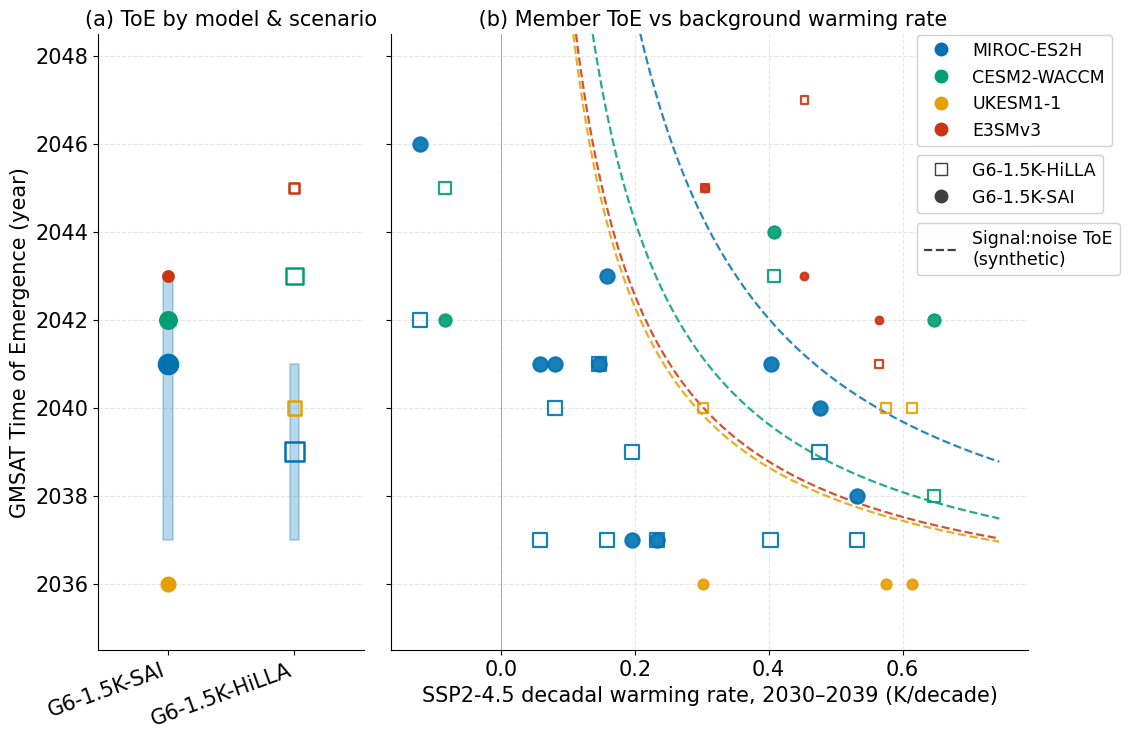

In [53]:
MODEL_COLORS = {
    'MIROC-ES2H':  '#0072B2',   # blue
    'CESM2-WACCM': '#009E73',   # bluish green
    'UKESM1-1':    '#E69F00',   # orange
    'E3SMv3':      '#CC3311',   # vermillion
}
SCEN_ORDER  = ['G6-1.5K-SAI', 'G6-1.5K-HiLLA']
SCEN_KEY    = {'G6-1.5K-SAI': 'SAI', 'G6-1.5K-HiLLA': 'HiLLA'}
SCEN_MARKER = {'HiLLA': 's', 'SAI': 'o'}     # hollow square / solid circle
# Fixed per-model marker size (largest first): when models coincide at the same x/y,
# drawing largest-to-smallest leaves every model visible as a nested marker.
MODEL_ORDER = ['MIROC-ES2H', 'CESM2-WACCM', 'UKESM1-1', 'E3SMv3']
MODEL_SIZE  = {'MIROC-ES2H': 190, 'CESM2-WACCM': 140, 'UKESM1-1': 95, 'E3SMv3': 55}

fig, (ax_l, ax_r) = plt.subplots(
    1, 2, figsize=(12, 8), sharey=True,
    gridspec_kw={'width_ratios': [1, 2.4], 'wspace': 0.06}
)

# ── LEFT: p66 ToE per model per scenario, + MIROC bootstrap box ──────────────
for x0, scen_label in enumerate(SCEN_ORDER):
    scen = SCEN_KEY[scen_label]
    for m in MODEL_ORDER:
        col = MODEL_COLORS[m]
        x = x0

        if m == 'MIROC-ES2H':
            boot = miroc_boot[scen]
            p5, p95 = np.percentile(boot, [5, 95])
            box_w = 0.075
            ax_l.add_patch(plt.Rectangle((x - box_w / 2, p5), box_w, p95 - p5,
                                         facecolor=col, alpha=0.28, edgecolor=col,
                                         linewidth=1.2, zorder=2))

        p66 = count_based_p66(member_toes[m][scen])
        marker = SCEN_MARKER[scen]
        face = 'none' if scen == 'HiLLA' else col
        if p66 is not None:
            ax_l.scatter([x], [p66], marker=marker, s=MODEL_SIZE[m], facecolors=face,
                        edgecolors=col, linewidths=1.8, zorder=4)

ax_l.set_xticks([0, 1])
ax_l.set_xticklabels(SCEN_ORDER, rotation=20, ha='right')
ax_l.set_xlim(-0.55, 1.55)
ax_l.set_ylabel('GMSAT Time of Emergence (year)', fontsize='medium')
ax_l.set_title('(a) ToE by model & scenario', fontsize='medium')
    #\n(p66 across members; box = MIROC-ES2H\nn=3 bootstrap, 5th–95th pct)',
     #         fontsize=11)
ax_l.grid(ls='--', alpha=0.3, axis='y')
for sp in ('top', 'right'):
    ax_l.spines[sp].set_visible(False)

# ── RIGHT: member ToE vs decadal SSP2-4.5 warming rate ───────────────────────
for m in MODEL_ORDER:
    col = MODEL_COLORS[m]
    tr = trends[m]
    for scen in ['HiLLA', 'SAI']:
        toes = member_toes[m][scen]
        n = min(len(tr), len(toes))
        xs = [tr[i] for i in range(n) if toes[i] is not None]
        ys = [toes[i] for i in range(n) if toes[i] is not None]
        marker = SCEN_MARKER[scen]
        face = 'none' if scen == 'HiLLA' else col
        ax_r.scatter(xs, ys, marker=marker, s=MODEL_SIZE[m] * 0.55, facecolors=face,
                    edgecolors=col, linewidths=1.6, zorder=4, alpha=0.9)

# ── theoretical signal:noise ToE curves, one per model (dashed) ──────────────
# Only meaningful for a positive assumed cooling/warming rate (ToE(rate) = 2035 + 1.645*sigma/rate
# diverges as rate -> 0+, and is undefined for rate <= 0), so the curve domain excludes rate <= 0
# even though a couple of individual members (e.g. one CESM2-WACCM member) have a slightly
# negative 2030-2039 trend and so have no corresponding theoretical curve value.
_all_rates = [t for m in MODEL_ORDER for t in trends[m]]
_pos_rates = [t for t in _all_rates if t > 0]
rate_range = np.linspace(0.05, max(_pos_rates) * 1.15, 300)
for m in MODEL_ORDER:
    col = MODEL_COLORS[m]
    toe_curve = sn_theoretical_toe(rate_range, model_sigma[m])
    ax_r.plot(rate_range, toe_curve, ls='--', color=col, lw=1.6, zorder=3, alpha=0.85)

# Pin the y-range to the actual ToE data (member ToEs + MIROC bootstrap) with small padding,
# so the asymptotic S:N curves (which blow up as rate -> 0+) don't wreck the autoscale — they
# simply run off the top of the visible range, as expected for an asymptotic relationship.
_all_toes = [t for m in MODEL_ORDER for scen in ['HiLLA', 'SAI'] for t in member_toes[m][scen] if t is not None]
_all_toes += miroc_boot['HiLLA'] + miroc_boot['SAI']
ax_l.set_ylim(min(_all_toes) - 1.5, max(_all_toes) + 1.5)

ax_r.set_xlabel('SSP2-4.5 decadal warming rate, 2030–2039 (K/decade)', fontsize='medium')
ax_r.set_title(' (b) Member ToE vs background warming rate', fontsize='medium')
ax_r.grid(ls='--', alpha=0.3)
ax_r.axvline(0, color='k', lw=0.7, alpha=0.3)
for sp in ('top', 'right'):
    ax_r.spines[sp].set_visible(False)
ax_r.tick_params(labelleft=False)

for ax in (ax_l, ax_r):
    ax.yaxis.set_major_locator(matplotlib.ticker.MaxNLocator(integer=True))

# ── legends, placed outside both axes so no data point is ever occluded ─────
model_handles = [Line2D([0], [0], marker='o', color=MODEL_COLORS[m], lw=0,
                       markerfacecolor=MODEL_COLORS[m], markersize=9, label=m)
                for m in MODEL_ORDER]
scen_handles = [
    Line2D([0], [0], marker='s', color='0.25', lw=0, markerfacecolor='none',
          markeredgecolor='0.25', markersize=9, label='G6-1.5K-HiLLA'),
    Line2D([0], [0], marker='o', color='0.25', lw=0, markerfacecolor='0.25',
          markeredgecolor='0.25', markersize=9, label='G6-1.5K-SAI'),
]
sn_handle = [Line2D([0], [0], color='0.25', lw=1.6, ls='--',
                    label='Signal:noise ToE\n(synthetic)')]
fig.legend(handles=model_handles, loc='upper left', bbox_to_anchor=(0.8, 0.89), fontsize='small', framealpha=0.9)
fig.legend(handles=scen_handles, loc='upper left', bbox_to_anchor=(0.8, 0.74), fontsize='small', framealpha=0.9)
          #fontsize=10, title='Scenario', framealpha=0.9)
fig.legend(handles=sn_handle, loc='upper left', bbox_to_anchor=(0.8, 0.655), fontsize='small', framealpha=0.9)

#fig.suptitle('Time of Emergence — GMSAT — cumulative paired t-test (p < 0.05)',
#            fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('Figures/ToE_GMSAT_ttest_two_panel.png', dpi=200, bbox_inches='tight')
plt.show()